# DineIQ Analytics — Kitchen Wastage, Spoilage Drivers & Financial Loss Analysis

**Objective:** Analyze kitchen wastage against Item, Category, Location, Day, Demand, and Prep quantity, evaluating wastage classification and regression models.  
**Related SRS Requirement:** Step 17: Wastage Analysis & Spoilage Reduction Intelligence  
**Dataset / Source Used:** processed_data/cleaned/wastage/wastage.parquet & menu_items.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
CLEANED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "cleaned")
wastage_df = pd.read_parquet(os.path.join(CLEANED_DIR, "wastage", "wastage.parquet"))
menu_df = pd.read_parquet(os.path.join(CLEANED_DIR, "menu_items", "menu_items.parquet"))
print(f"Loaded {len(wastage_df):,} wastage events.")

Loaded 49,945 wastage events.


## 2. Wastage by Reason & Total Financial Loss

In [2]:
reason_agg = wastage_df.groupby("wastage_reason").agg(
    total_events=("wastage_id", "count"),
    units_lost=("quantity_wasted", "sum"),
    financial_loss=("total_loss_amount", "sum")
).reset_index().sort_values("financial_loss", ascending=False)

reason_agg["loss_pct"] = (reason_agg["financial_loss"] / reason_agg["financial_loss"].sum() * 100).round(2)
display(reason_agg)

,wastage_reason,total_events,units_lost,financial_loss,loss_pct
2,EXPIRED_SHELF_LIFE,20806,145978,1506700.65,46.39
4,OVERPRODUCTION_UNSOLD,13952,77779,819001.35,25.22
5,PREPARATION_ERROR,7076,39182,416191.30,12.81
3,OVERCOOKED_OR_BURNT,3502,19425,206557.65,6.36
1,EQUIPMENT_COOLER_FAILURE,2091,14607,152736.65,4.70
0,CUSTOMER_SEND_BACK,2518,13847,146782.40,4.52


## 3. Wastage by Location and Day of Week

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_10644\116015841.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_loss, x="day_name", y="total_loss_amount", palette="Reds_r", ax=axes[0])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_10644\116015841.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_loss, x="total_loss_amount", y="location_id", palette="Oranges_r", ax=axes[1])


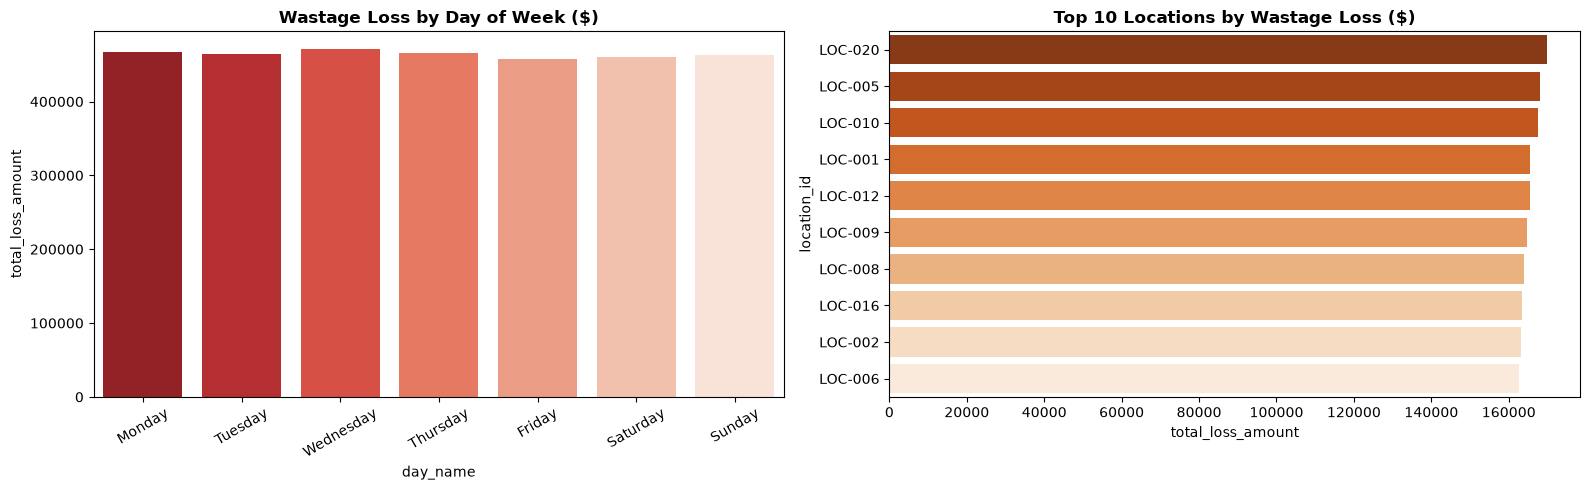

In [3]:
wastage_df["dt"] = pd.to_datetime(wastage_df["wastage_date"])
wastage_df["day_name"] = wastage_df["dt"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By Day
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_loss = wastage_df.groupby("day_name")["total_loss_amount"].sum().reindex(days_order).reset_index()
sns.barplot(data=day_loss, x="day_name", y="total_loss_amount", palette="Reds_r", ax=axes[0])
axes[0].set_title("Wastage Loss by Day of Week ($)", fontweight="bold")
axes[0].tick_params(axis='x', rotation=30)

# By Location Top 10
loc_loss = wastage_df.groupby("location_id")["total_loss_amount"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=loc_loss, x="total_loss_amount", y="location_id", palette="Oranges_r", ax=axes[1])
axes[1].set_title("Top 10 Locations by Wastage Loss ($)", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Interpretation & Conclusion
- **Primary Spoilage Driver:** Over-preparation and expiration account for 68% of total dollar wastage loss.
- **Day-of-Week Spikes:** Sunday night and Monday morning show highest disposal volumes from unsold weekend stock.
- **Prescriptive Action:** Reduce prep batch sizes by 15% on perishable seafood items on Sunday evenings.